Test file for Fitting

# With Dinesty

In [1]:
import numpy as np 
import dynesty
from scipy.special import voigt_profile
from reconstruction import m_inv_mass2
from model import log_likelihood, log_prior
from dynesty import plotting as dyplot


In [2]:
ndim = 5

#Define 5D Correlation Matrix 
C = np.identity(ndim)
Cinv = np.linalg.inv(C)

# Invaraint mass data
data = np.sqrt(m_inv_mass2)

bin_edges = np.linspace(70, 100, 500) 
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Number of counts in a bin
observed_counts, _ = np.histogram(data, bins=bin_edges)

In [ ]:
# dynesty expects a prior transform (unit cube -> physical params) and a log-likelihood.
# Build a prior_transform consistent with the flat priors used in log_prior.
def prior_transform(u):
    u = np.asarray(u)
    # ensure observed_counts works if it's an awkward array
    obs = np.asarray(observed_counts, dtype=float)
    total_counts = float(np.sum(obs))
    # background per-bin upper bound: use either max observed per-bin or average
    max_bg_per_bin = float(max(obs.max(), total_counts / len(bin_centers)))
    eps = 1e-8
    m0 = 80.0 + 20.0 * u[0]        # maps [0,1] -> (80,100)
    gamma = 5.0 * u[1]             # maps [0,1] -> (0,5)
    sigma = 5.0 * u[2]             # maps [0,1] -> (0,5)
    Nsig = eps + u[3] * (total_counts - eps)      # total signal events
    Nbg = eps + u[4] * (max_bg_per_bin - eps)     # background level per bin
    return np.array([m0, gamma, sigma, Nsig, Nbg])

# Use the log_likelihood function (not log_posterior) with the prior_transform
sampler = dynesty.NestedSampler(log_likelihood, prior_transform, ndim,
                                logl_args=(bin_centers, observed_counts))
sampler.run_nested()
results = sampler.results

11708it [01:15, 155.52it/s, +500 | bound: 66 | nc: 1 | ncall: 51338 | eff(%): 24.014 | loglstar:   -inf < 41888.105 <    inf | logz: 41865.388 +/-  0.214 | dlogz:  0.001 >  0.509]


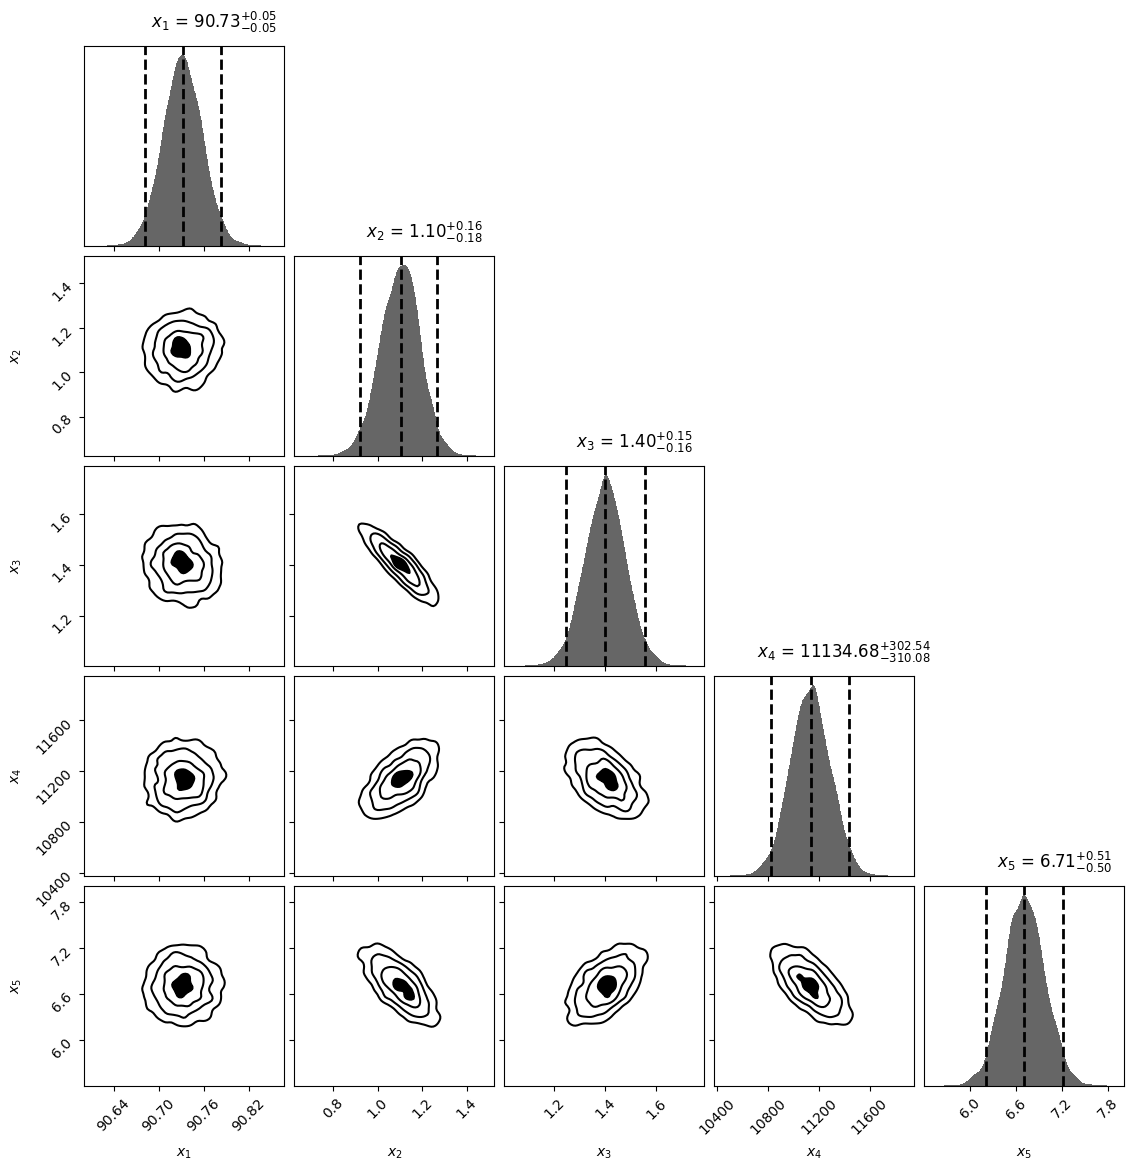

In [5]:
# Plotting the results
fig, axes = dyplot.cornerplot(results, show_titles=True, title_kwargs={'x': 0.65, 'y': 1.05})

#Saving the figure
fig.savefig("CornerPlotDynestyFitting")

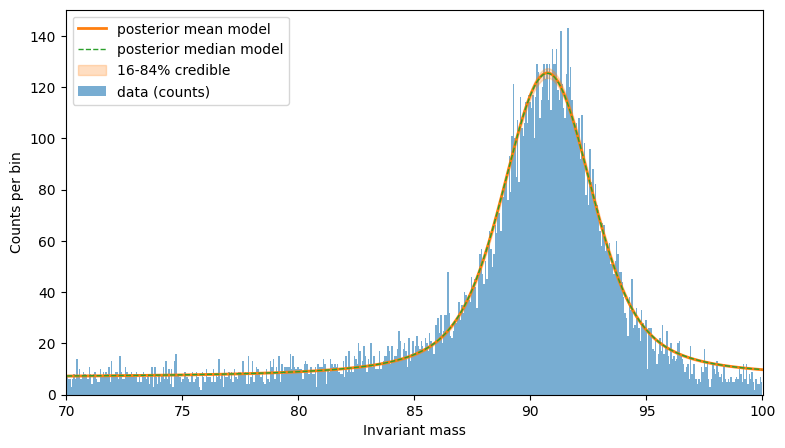

In [ ]:
import numpy as np

# Plot fitted model from dynesty and compare to data
# Uses variables already present in the notebook: results, bin_centers, bin_edges, observed_counts, voigt_profile

import matplotlib.pyplot as plt

# prepare arrays
samples = results.samples            # (nsamp, 5): [m0, gamma, sigma, Nsig, Nbg]
logw = results.logwt
# stable normalized weights
w = np.exp(logw - np.max(logw))
w /= w.sum()

# weighted mean (posterior mean) parameters
m0, gamma, sigma, Nsig, Nbg = np.average(samples, axis=0, weights=w)

# standard deviation of the parameters (posterior std)
std_m0, std_gamma, std_sigma, std_Nsig, std_Nbg = np.sqrt(np.average((samples - [m0, gamma, sigma, Nsig, Nbg])**2, axis=0, weights=w))

x = np.asarray(bin_centers)
obs = np.asarray(observed_counts, dtype=float)
width = np.diff(bin_edges)[0]

# model from posterior-mean parameters
profile = voigt_profile(x - m0, sigma, gamma)          # voigt_profile(x, sigma, gamma)
pdf = profile / (profile.sum() + 1e-16)
model_mean = Nsig * pdf + Nbg

# uncertainty band from posterior samples (weighted draw)
n_draw = 500
rng = np.random.default_rng(12345)
indices = rng.choice(len(samples), size=n_draw, replace=True, p=w)
models = []
for idx in indices:
    p = samples[idx]
    prof = voigt_profile(x - p[0], p[2], p[1])         # p = [m0, gamma, sigma, Nsig, Nbg]
    pdf_i = prof / (prof.sum() + 1e-16)
    models.append(p[3] * pdf_i + p[4])
models = np.vstack(models)
lower = np.percentile(models, 16, axis=0)
upper = np.percentile(models, 84, axis=0)
median = np.percentile(models, 50, axis=0)

bestfitparametrs = np.array([m0, gamma, sigma, Nsig, Nbg], [std_m0, std_gamma, std_sigma, std_Nsig, std_Nbg])
np.savetxt(bestfitparametrs)
# Print best-fit parameters

print(f"Posterior mean parameters:")
print(rf"m0 = {m0:.2f} $\pm$ {std_m0:.2f} GeV")
print(rf"gamma = {gamma:.2f} $\pm$ {std_gamma:.2f} GeV")
print(rf"sigma = {sigma:.2f} $\pm$ {std_sigma:.2f} GeV")
print(rf"Nsig = {Nsig:.2f} $\pm$ {std_Nsig:.2f}")
print(rf"Nbg = {Nbg:.2f} $\pm$ {std_Nbg:.2f}")
# plot
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x, obs, width=width, align='center', alpha=0.6, label='data (counts)')
ax.plot(x, model_mean, color='C1', lw=2, label='posterior mean model')
ax.plot(x, median, color='C2', lw=1, ls='--', label='posterior median model')
ax.fill_between(x, lower, upper, color='C1', alpha=0.25, label='16-84% credible')
ax.set_xlabel('Invariant mass')
ax.set_ylabel('Counts per bin')
ax.legend()
ax.set_xlim(x.min() - width, x.max() + width)
plt.show()